# Lab 6 - Vision Transformer

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, May 2nd (23:59)**

---

## Learning objectives
Vision Transformer (ViT-B/16 base version) vs ResNet-18  

By the end of this lab, you should be able to:

1. Split an image into patches and understand image tokens.
2. Convert patches into embeddings.
3. Add positional embeddings and a `[CLS]` token.
4. Inspect a pretrained Vision Transformer.
5. Fine-tune pretrained ViT and ResNet models using transfer learning.
6. Compare CNN vs ViT behavior in terms of accuracy, speed, and architecture.


We will **not train ViT from scratch**. That would require large datasets and strong hardware.  
Instead, we will:

- build small components manually for understanding,
- load pretrained models,
- replace their classification heads,
- freeze the backbones,
- train only the final classifiers.

>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


## 0. Setup

This notebook supports both:

- **Google Colab with GPU**
- **Local CPU laptops**

On CPU, use a smaller subset of the dataset and fewer epochs. 

In [1]:
import os
import time
import random
import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IS_GPU = device.type == "cuda"

CONFIG = {
    "image_size": 224,
    "patch_size": 16,
    "num_classes": 10,
    "batch_size": 32 if IS_GPU else 8,
    "num_workers": 2 if IS_GPU else 0,
    "train_subset": 3000 if IS_GPU else 600,
    "test_subset": 1000 if IS_GPU else 300,
    "epochs": 3 if IS_GPU else 1,
    "lr": 1e-3,
}
CONFIG

Using device: cuda


{'image_size': 224,
 'patch_size': 16,
 'num_classes': 10,
 'batch_size': 32,
 'num_workers': 2,
 'train_subset': 3000,
 'test_subset': 1000,
 'epochs': 3,
 'lr': 0.001}

## 1. Dataset: CIFAR-10 resized to 224×224

CIFAR-10 images are originally **32×32**, but ImageNet-pretrained ViT and ResNet models expect around **224×224** input images.

So we resize CIFAR-10 images to 224×224 and normalize them using ImageNet statistics.

In [3]:
# ImageNet normalization values used by pretrained torchvision models.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

root = "./data"
train_full = datasets.CIFAR10(root=root, train=True, download=True, transform=train_transform)
test_full = datasets.CIFAR10(root=root, train=False, download=True, transform=test_transform)

class_names = train_full.classes
class_names

100%|██████████| 170M/170M [00:04<00:00, 41.5MB/s] 


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [4]:
# Use a subset to keep the lab fas :) 
train_indices = list(range(CONFIG["train_subset"]))
test_indices = list(range(CONFIG["test_subset"]))

train_ds = Subset(train_full, train_indices)
test_ds = Subset(test_full, test_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
)

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))
print("Classes:", class_names)

Train samples: 3000
Test samples: 1000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


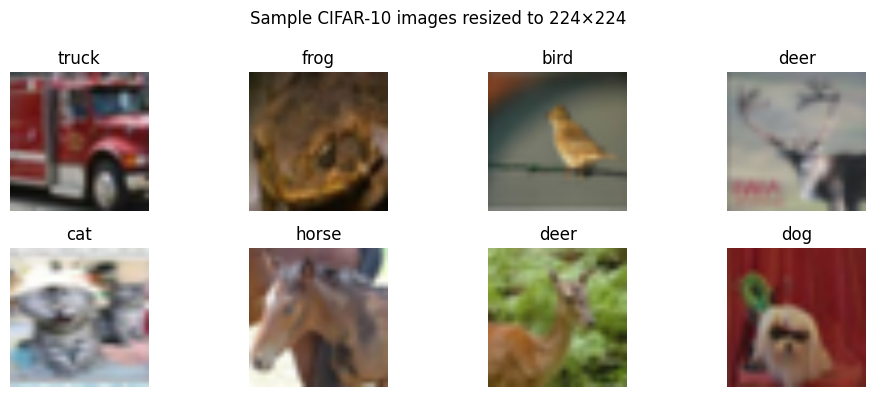

In [5]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Undo ImageNet normalization for visualization."""
    img = img_tensor.clone().detach().cpu()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    return img.clamp(0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 images resized to 224×224")
plt.tight_layout()
plt.show()

# Part A : Build ViT input components manually

Before using a pretrained ViT, we manually build the input pipeline:

1. Image → patches
2. Patches → flattened vectors
3. Flattened vectors → embeddings
4. Add positional embeddings
5. Add `[CLS]` token

## 2. Step 1 : Split image into patches

For ViT-B/16:

- image size = 224×224
- patch size = 16×16
- number of patches per side = 224 / 16 = 14
- total patches = 14 × 14 = 196

Each patch becomes one token.

Image shape: torch.Size([3, 224, 224])
Label: truck


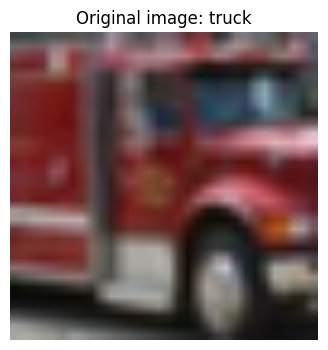

In [6]:
# Pick one image for visualization.
sample_img = images[0]  # shape: [3, 224, 224]
sample_label = labels[0].item()
print("Image shape:", sample_img.shape)
print("Label:", class_names[sample_label])

plt.figure(figsize=(4, 4))
plt.imshow(denormalize(sample_img).permute(1, 2, 0))
plt.title(f"Original image: {class_names[sample_label]}")
plt.axis("off")
plt.show()

In [7]:
def image_to_patches(img, patch_size=16):
    """
    Convert one image tensor [C, H, W] into patches.

    Expected output shape:
        [num_patches, C, patch_size, patch_size]
    """
    C, H, W = img.shape
    assert H % patch_size == 0 and W % patch_size == 0, "Image size must be divisible by patch size."

    # TODO 1:
    # Use torch.unfold to split the image into non-overlapping patches.
    # Documentation: https://docs.pytorch.org/docs/stable/generated/torch.nn.Unfold.html
    
    unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
    # unfold attend [B, C, H, W] → sortie [1, C*P*P, num_patches]
    patches = unfold(img.unsqueeze(0))          # [1, C*P*P, num_patches]
    patches = patches.squeeze(0).T              # [num_patches, C*P*P]
    num_patches = patches.shape[0]
    patches = patches.reshape(num_patches, C, patch_size, patch_size)


    # TODO: replace None with your implementation.
    return patches

In [8]:
# Test your implementation.
patches = image_to_patches(sample_img, CONFIG["patch_size"])

# TODO 2:
# Print the shape of patches.
# Expected: [196, 3, 16, 16]
patches = image_to_patches(sample_img, CONFIG["patch_size"])
print("Patches shape:", patches.shape)



Patches shape: torch.Size([196, 3, 16, 16])


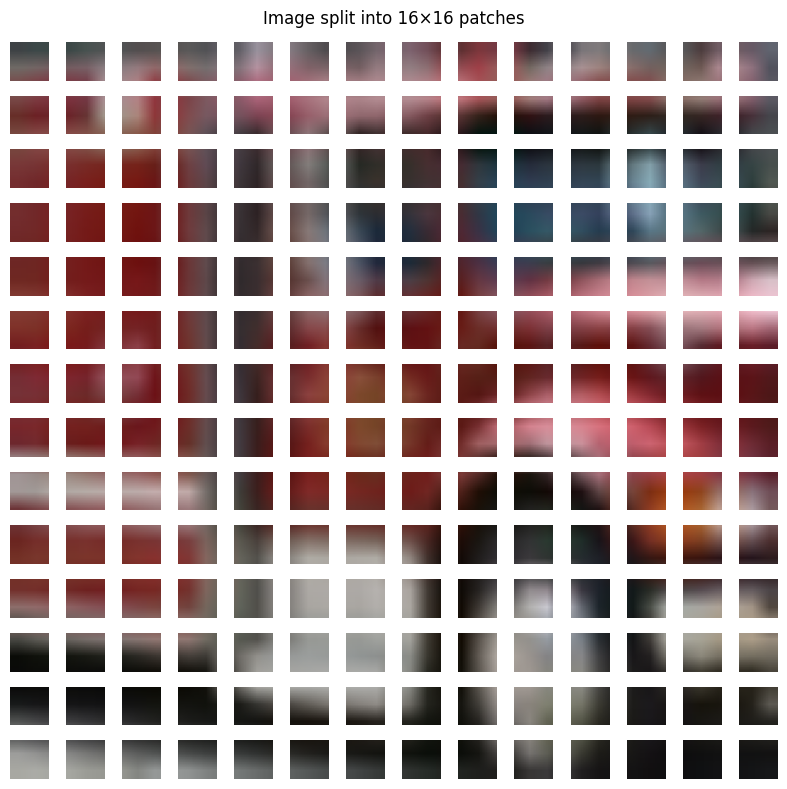

In [9]:
def show_patch_grid(patches, grid_size=14, max_patches=196):
    """Visualize patches in their original grid order."""
    plt.figure(figsize=(8, 8))
    for i in range(min(max_patches, patches.shape[0])):
        plt.subplot(grid_size, grid_size, i + 1)
        patch = denormalize(patches[i]).permute(1, 2, 0)
        plt.imshow(patch)
        plt.axis("off")
    plt.suptitle("Image split into 16×16 patches")
    plt.tight_layout()
    plt.show()

show_patch_grid(patches, grid_size=CONFIG["image_size"] // CONFIG["patch_size"])

### Checkpoint question

If we change the patch size from 16×16 to 32×32 while keeping the image size 224×224:

1. How many patches do we get? 
224/32= 7 patches par coté donc au total on a 7x7=49 patches
2. What happens to computation cost?
L'attention est quadratique en nombres de tokens. Donc avec 49 tokens au lieu de 196, le calcul est environ 16 fois plus rapode 
3. What happens to spatial detail?
 Chaque patch couvre une zone plus grande de l'image, donc on perd de la granularité spatiale. Le modèle voit moins de détails fins, ce qui peut nuire aux performances sur des tâches nécessitant une précision locale

## 3. Step 2.1 : Patch → Embedding

A transformer cannot process image patches directly. It expects vectors.

For each patch:

1. Flatten it into a vector.
2. Apply a linear projection to map it into an embedding dimension.

For RGB 16×16 patches:

\[
16 x 16 x 3 = 768
\]

So each flattened patch has 768 values.

In [10]:
patch_size = CONFIG["patch_size"]
patch_dim = 3 * patch_size * patch_size
embed_dim = 768

print("Patch dimension:", patch_dim)
print("Embedding dimension:", embed_dim)

Patch dimension: 768
Embedding dimension: 768


In [11]:
def flatten_patches(patches):
    """
    Input:
        patches: [num_patches, C, P, P]
    Output:
        flat_patches: [num_patches, C*P*P]
    """
    # TODO 3:
    # Flatten each patch into a 1D vector.
    flat_patches = patches.flatten(start_dim=1)
    return flat_patches

flat_patches = flatten_patches(patches)
print("Flattened patches shape:", flat_patches.shape)

# a small check 
assert flat_patches.shape == (196, 768)

Flattened patches shape: torch.Size([196, 768])


In [12]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_dim, embed_dim):
        super().__init__()
        # TODO 4:
        # Define a linear layer that maps patch_dim -> embed_dim.
        self.proj = nn.Linear(patch_dim, embed_dim)

    def forward(self, flat_patches):
        # TODO 5:
        # Apply the projection to flat_patches.
        embeddings = self.proj(flat_patches)
        return embeddings

patch_embedder = PatchEmbedding(patch_dim, embed_dim)
patch_embeddings = patch_embedder(flat_patches)
print("Patch embeddings shape:", patch_embeddings.shape)

# a small check
assert patch_embeddings.shape == (196, 768)

Patch embeddings shape: torch.Size([196, 768])


### Checkpoint question

What is the difference between:

- the flattened patch vector
- the patch embedding vector

Why do we need the linear projection?

## 4. Step 2.2 : Positional embeddings

Transformers process tokens as a sequence. Without positional information, the model does not know where each patch came from.

So we add a learned position vector to each patch embedding:

\[
x_i = e_i + p_i
\]

where:

- \(e_i\) = patch embedding
- \(p_i\) = positional embedding
- \(x_i\) = final input token for patch \(i\)

In [15]:
num_patches = (CONFIG["image_size"] // CONFIG["patch_size"]) ** 2
print("Number of patches:", num_patches)

class AddPositionEmbedding(nn.Module):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        # TODO 6:
        # Create learnable positional embeddings of shape [1, num_patches, embed_dim].
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, embed_dim))

    def forward(self, patch_embeddings):
        """
        patch_embeddings shape can be:
            [num_patches, embed_dim] or [batch, num_patches, embed_dim]
        """
        if patch_embeddings.dim() == 2:
            patch_embeddings = patch_embeddings.unsqueeze(0)

        # TODO 7:
        # Add pos embeddings to patch embeddings.
        x = patch_embeddings + self.pos_embed
        return x

pos_layer = AddPositionEmbedding(num_patches, embed_dim)
x_with_pos = pos_layer(patch_embeddings)
print("With position shape:", x_with_pos.shape)

# a check
assert x_with_pos.shape == (1, 196, 768)

Number of patches: 196
With position shape: torch.Size([1, 196, 768])


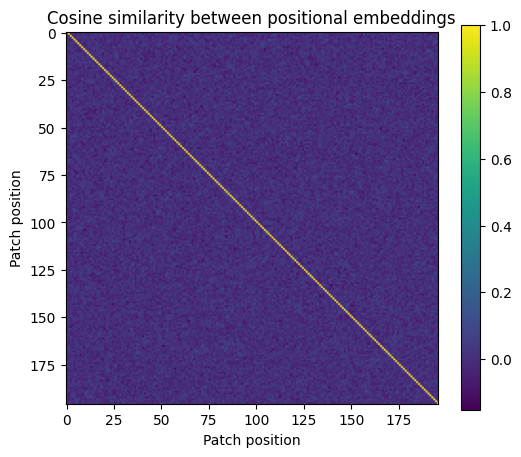

In [16]:
# Visualization: cosine similarity between positional embeddings.
# This shows how positions are represented before training (random initially).
with torch.no_grad():
    P = pos_layer.pos_embed.squeeze(0)  # [num_patches, embed_dim]
    P_norm = P / (P.norm(dim=1, keepdim=True) + 1e-8)
    sim = P_norm @ P_norm.T

plt.figure(figsize=(6, 5))
plt.imshow(sim.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Cosine similarity between positional embeddings")
plt.xlabel("Patch position")
plt.ylabel("Patch position")
plt.show()


## 5. Step 2.3 : Add the `[CLS]` token

After patch embedding and positional embedding, we have many token vectors:

\[
x_1, x_2, ..., x_n
\]

But for image classification, we need **one vector** to represent the whole image.

So ViT adds a special learnable token at the beginning:

\[
[CLS], x_1, x_2, ..., x_n
\]

The `[CLS]` token interacts with all patch tokens through attention. After the encoder, the final `[CLS]` vector is used for classification.

In [17]:
class AddCLSToken(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        # TODO 8:
        # Create a learnable CLS token of shape [1, 1, embed_dim].
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

    def forward(self, x):
        """
        x: [batch, num_patches, embed_dim]
        output: [batch, num_patches + 1, embed_dim]
        """
        B = x.shape[0]

        # TODO 9:
        # Expand CLS token to batch size and concatenate it before patch tokens.
        cls_tokens = self.cls_token.expand(B, -1, -1)
        out = torch.cat([cls_tokens, x], dim=1)
        return out

cls_layer = AddCLSToken(embed_dim)
x_final = cls_layer(x_with_pos)
print("Final ViT input sequence shape:", x_final.shape)

# a check 
assert x_final.shape == (1, 197, 768)

Final ViT input sequence shape: torch.Size([1, 197, 768])


### Checkpoint question

Why do we use one `[CLS]` token instead of one `[CLS]` token per patch?


# Part B : Load pretrained models

Now that we understand the input pipeline, we use pretrained models.

We will compare:

- **ViT-B/16**: transformer-based model
- **ResNet-18**: CNN-based model

For transfer learning, we freeze the backbone and train only the final classification layer.

## 6. Load pretrained ViT and inspect its structure

We use torchvision's pretrained ViT-B/16.

This model was pretrained on ImageNet. It expects:

- image size: 224×224
- patch size: 16×16
- patch tokens: 196
- plus one `[CLS]` token: 197 tokens total

In [18]:
# Load pretrained ViT-B/16.
# The first time this runs, it downloads weights.
vit_weights = models.ViT_B_16_Weights.IMAGENET1K_V1
vit = models.vit_b_16(weights=vit_weights)
vit.eval()
vit = vit.to(device)

print(vit)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 49.9MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [19]:
# Inspect  shapes
print("Patch projection layer:", vit.conv_proj)
print("Hidden dimension:", vit.hidden_dim)
print("Number of encoder layers:", len(vit.encoder.layers))
print("Classification head:", vit.heads)

Patch projection layer: Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
Hidden dimension: 768
Number of encoder layers: 12
Classification head: Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)


## 7. Extract tokens before and after the ViT encoder

We will inspect:

- token embeddings before the encoder
- token representations after the encoder
- the `[CLS]` vector

In [20]:
@torch.no_grad()
def get_vit_tokens(model, batch_images):
    """
    Return tokens before and after the encoder for torchvision ViT.

    batch_images: [B, 3, 224, 224]
    """
    model.eval()
    x = batch_images.to(device)

    # Patchify through conv projection.
    x = model.conv_proj(x)  # [B, hidden_dim, 14, 14]

    # Flatten spatial dimensions into sequence.
    x = x.flatten(2).transpose(1, 2)  # [B, 196, hidden_dim]

    # Add CLS token.
    B = x.shape[0]
    cls_token = model.class_token.expand(B, -1, -1)
    x = torch.cat([cls_token, x], dim=1)  # [B, 197, hidden_dim]

    tokens_before_encoder = x.clone()

    # Encoder includes positional embedding internally in torchvision.
    tokens_after_encoder = model.encoder(x)

    return tokens_before_encoder, tokens_after_encoder

small_batch = images[:4].to(device)
before_tokens, after_tokens = get_vit_tokens(vit, small_batch)

print("Before encoder:", before_tokens.shape)
print("After encoder:", after_tokens.shape)
print("CLS after encoder:", after_tokens[:, 0, :].shape)

Before encoder: torch.Size([4, 197, 768])
After encoder: torch.Size([4, 197, 768])
CLS after encoder: torch.Size([4, 768])


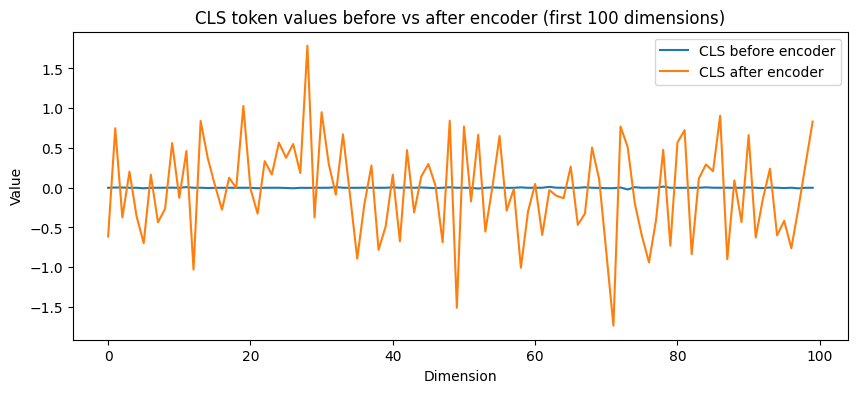

In [21]:
# Plot CLS vector before and after encoder for the same image.
idx = 0
cls_before = before_tokens[idx, 0].detach().cpu()
cls_after = after_tokens[idx, 0].detach().cpu()

plt.figure(figsize=(10, 4))
plt.plot(cls_before[:100], label="CLS before encoder")
plt.plot(cls_after[:100], label="CLS after encoder")
plt.title("CLS token values before vs after encoder (first 100 dimensions)")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.legend()
plt.show()

In [22]:
# TODO 10:
# Compute and print the L2 norm of CLS before and after the encoder.

cls_before_norm = cls_before.norm().item()
cls_after_norm = cls_after.norm().item()

print("CLS norm before:", cls_before_norm)
print("CLS norm after:", cls_after_norm)

CLS norm before: 0.4450820982456207
CLS norm after: 15.781667709350586


# Part C : Transfer learning: ViT vs ResNet

We now adapt pretrained models to CIFAR-10.

Strategy:

1. Load pretrained model.
2. Freeze all backbone parameters.
3. Replace the final classifier head with a new layer for 10 classes.
4. Train only the new classifier head. (feature extraction from the previous lecture 😉)


## 8. Helper functions for training and evaluation

In [23]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    return running_loss / total, correct / total, all_preds, all_labels


def fit_model(model, train_loader, test_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    start = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, test acc={test_acc:.4f}")

    elapsed = time.time() - start
    return history, elapsed

## 9. Build transfer-learning ResNet-18

ResNet-18 is a CNN. Its final classifier is called `fc`.

In [25]:
def build_resnet18_transfer(num_classes=10, freeze_backbone=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    if freeze_backbone:
        # TODO 11:
        # Freeze all model parameters.
        for param in model.parameters():
            param.requires_grad = False

        

    in_features = model.fc.in_features

    # TODO 12:
    # Replace model.fc with a the Linear layer 
    model.fc = nn.Linear(in_features, num_classes)

    return model

resnet_model = build_resnet18_transfer(CONFIG["num_classes"], freeze_backbone=True).to(device)
print(resnet_model.fc)
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Linear(in_features=512, out_features=10, bias=True)
Trainable parameters: 5130


## 10. Build transfer-learning ViT-B/16

In torchvision ViT, the final classifier is stored inside `model.heads`.

In [26]:
def build_vit_transfer(num_classes=10, freeze_backbone=True):
    weights = models.ViT_B_16_Weights.IMAGENET1K_V1
    model = models.vit_b_16(weights=weights)

    if freeze_backbone:
        # TODO 13:
        # Freeze all model parameters.
        for param in model.parameters():
            param.requires_grad = False
        

    in_features = model.heads.head.in_features

    # TODO 14:
    # Replace model.heads.head with the new Linear layer 
    model.heads.head = nn.Linear(in_features, num_classes)

    return model

vit_model = build_vit_transfer(CONFIG["num_classes"], freeze_backbone=True).to(device)
print(vit_model.heads)
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Sequential(
  (head): Linear(in_features=768, out_features=10, bias=True)
)
Trainable parameters: 7690


## 11. Train ResNet-18 head

In [27]:
resnet_history, resnet_time = fit_model(
    resnet_model,
    train_loader,
    test_loader,
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    device=device,
)
print(f"ResNet training time: {resnet_time:.1f} seconds")


Epoch 1/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=1.6070, train acc=0.4820, test acc=0.6480
Epoch 2/3


  0%|          | 0/94 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a642804dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a642804dee0>^^

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        
assert self._parent_pid == os.getpid(), 'can only test a child process'  self._shutdown_workers()
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
          ^^ ^ ^^^^^^^^^^^^^^^^^^^^^^

train loss=1.0142, train acc=0.6990, test acc=0.7040
Epoch 3/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=0.8186, train acc=0.7547, test acc=0.7190
ResNet training time: 28.6 seconds


## 12. Train ViT head

ViT-B/16 is heavier than ResNet-18. On CPU, this can be slow. If no gpu used, use a subset of the data!!

In [28]:
vit_history, vit_time = fit_model(
    vit_model,
    train_loader,
    test_loader,
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    device=device,
)
print(f"ViT training time: {vit_time:.1f} seconds")


Epoch 1/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=0.6475, train acc=0.8503, test acc=0.9240
Epoch 2/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=0.2206, train acc=0.9440, test acc=0.9390
Epoch 3/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=0.1625, train acc=0.9563, test acc=0.9390
ViT training time: 185.1 seconds


## 13. Compare training curves

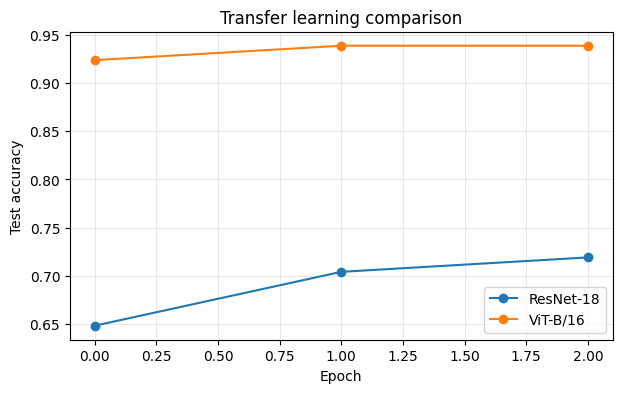

In [29]:
# Plot test accuracies for both models on the same chart.
plt.figure(figsize=(7, 4))
plt.plot(resnet_history["test_acc"], marker="o", label="ResNet-18")
plt.plot(vit_history["test_acc"], marker="o", label="ViT-B/16")
plt.title("Transfer learning comparison")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [30]:
print("ResNet final test accuracy:", resnet_history["test_acc"][-1])
print("ViT final test accuracy:", vit_history["test_acc"][-1])
print("ResNet training time:", resnet_time)
print("ViT training time:", vit_time)

ResNet final test accuracy: 0.719
ViT final test accuracy: 0.939
ResNet training time: 28.58450961112976
ViT training time: 185.13537764549255


## 14. Confusion matrix

Use this to inspect which classes are confused by each model.

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

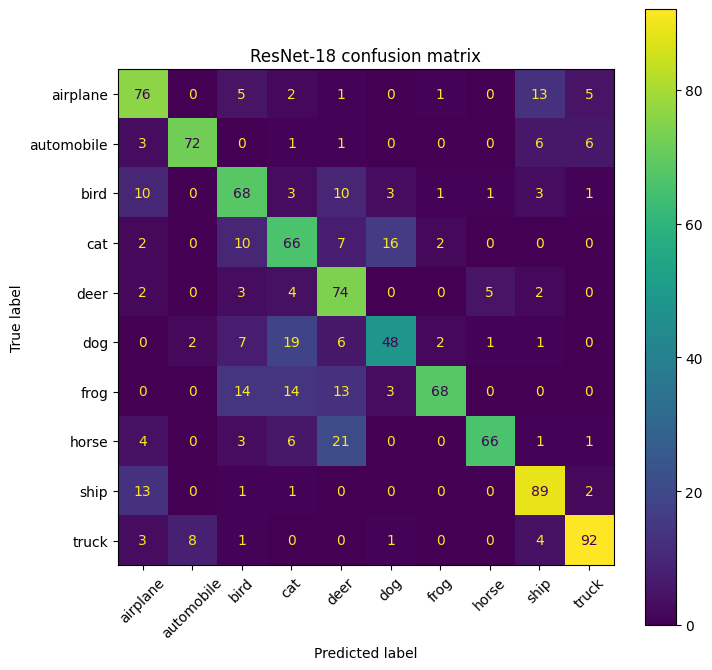

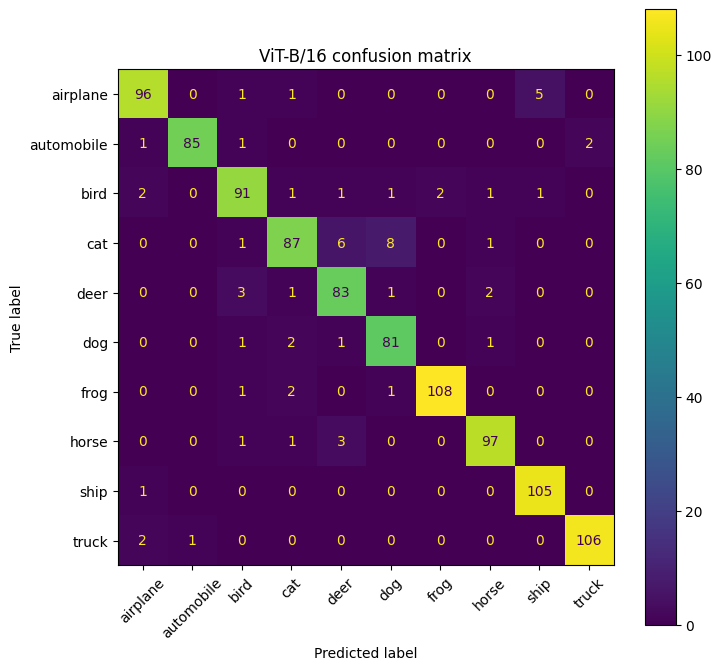

In [31]:
criterion = nn.CrossEntropyLoss()
_, _, resnet_preds, resnet_labels = evaluate(resnet_model, test_loader, criterion, device)
_, _, vit_preds, vit_labels = evaluate(vit_model, test_loader, criterion, device)

cm = confusion_matrix(resnet_labels, resnet_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("ResNet-18 confusion matrix")
plt.show()

cm = confusion_matrix(vit_labels, vit_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("ViT-B/16 confusion matrix")
plt.show()

# Final discussion questions

Answer briefly:

1. Why is transfer learning useful here?
Avec le transfer learning, on réutilise un modèle déjà entraîné sur des millions d'images. Il suffit de l'adapter à notre tâche : c'est plus rapide et plus précis

2. In your experiment, which model trained faster: ResNet or ViT? Why?
ResNet: Il utilise des convolutions locales, ce qui est plus léger à calculer. ViT analyse l'image entière patch par patch avec de l'attention, ce qui est plus coûteux

3. If you had a very small dataset, would you prefer CNN or ViT? Explain.
CNN car ViT a besoin de beaucoup de données pour bien apprendre. Le CNN a des règles intégrées (localité, translation) qui lui permettent de bien fonctionner même avec peu d'exemples